In [ ]:
%pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 37.1 MB/s eta 0:00:00


,Nazwa,Liczba Atomów,Liczba Wiązań,LogP,Masa
5,Laktoza,23,24,-5.397200,342.297000
3,Reswerartol,21,21,5.510300,286.459000
2,Retinol,21,21,5.510300,286.459000
1,Kwas hialuronowy,15,15,-3.077600,221.209000
0,Kwas askorbinowy,12,12,-1.407400,176.124000
4,Galaktoza,12,12,-3.221400,180.156000
8,Benzoesan Sodu,10,9,-2.945900,144.105000
7,Niacynamid,9,9,0.180500,122.127000
6,Furan,5,5,1.279600,68.075000


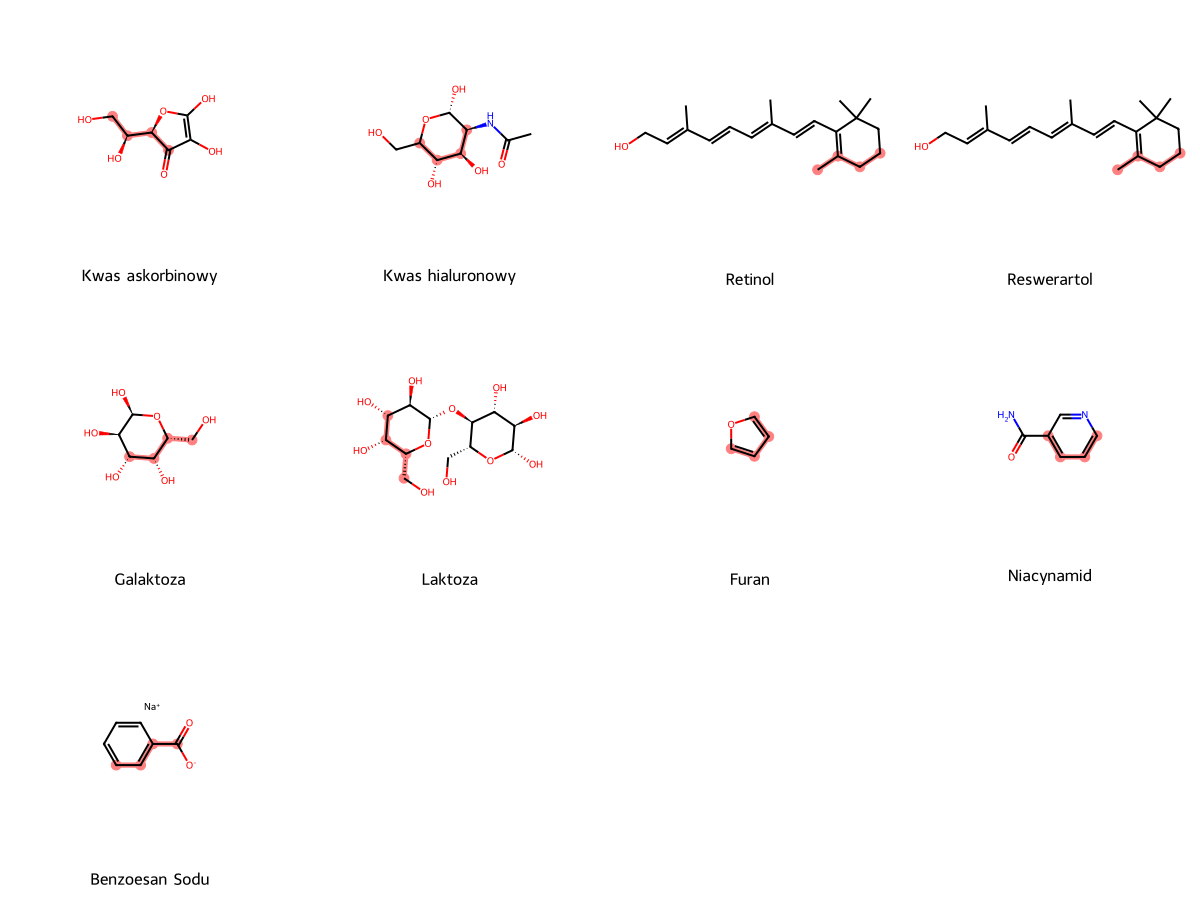

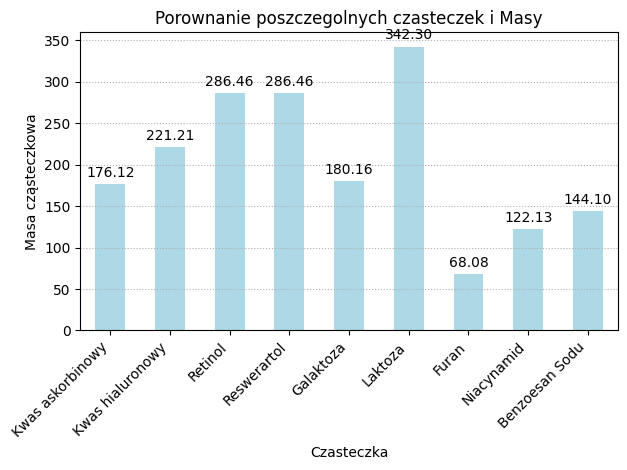

In [ ]:
#Nudno bylo w pracy to sobie pocwiczylem cos :D
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from IPython.display import display
import pandas as pd
from rdkit.Chem import rdFMCS
from rdkit.Chem.Draw import MolsToGridImage
from rdkit.Chem.Draw import SimilarityMaps
import matplotlib.pyplot as plt



molecules=[("Kwas askorbinowy", "C([C@@H]([C@@H]1C(=O)C(=C(O1)O)O)O)O"),
           ("Kwas hialuronowy", "[H][C@](C([H])(CO)O[C@@](O)([H])[C@@](NC(C)=O)1[H])(O)[C@@]1(O)[H]"),
            ("Retinol", "CC1=C(C(CCC1)(C)C)/C=C/C(=C/C=C/C(=C/CO)/C)/C"),
            ("Reswerartol", "CC1=C(C(CCC1)(C)C)/C=C/C(=C/C=C/C(=C/CO)/C)/C"),
           ("Galaktoza", "C([C@@H]1[C@@H]([C@@H]([C@H]([C@H](O1)O)O)O)O)O"),
           ("Laktoza", "C([C@@H]1[C@@H]([C@@H]([C@H]([C@@H](O1)O[C@@H]2[C@H](O[C@H]([C@@H]([C@H]2O)O)O)CO)O)O)O)O"),
           ("Furan", "C1=COC=C1"),
           ("Niacynamid", "c1cc(cnc1)C(=O)N"),
           ("Benzoesan Sodu", "O=C([O-])C1=CC=CC=C1.[Na+]")

]
data=[] #Tabela Dane
mols=[] #Tabela Rysunki
for name, smiles in molecules:
    name =(name)
    mol =Chem.MolFromSmiles(smiles)
    mol_H = Chem.AddHs(mol)
    mols.append(mol)


    Atomy = mol.GetNumAtoms()
    Wiązania =mol.GetNumBonds()
    LogP = Descriptors.MolLogP(mol)
    Masa = Descriptors.MolWt(mol)
    data.append([name, Atomy, Wiązania, LogP, Masa])
    df=pd.DataFrame(data,columns=["Nazwa", "Liczba Atomów", "Liczba Wiązań", "LogP", "Masa"])
    df_1 = df.sort_values(by="Liczba Atomów", ascending=False)
styled_df =df_1.style.set_properties(**{
      'background-color': "lightblue",
      'color': 'black'
  })
######################################################################################
ax =df.plot(kind='bar', x='Nazwa', y='Masa', color='lightblue', legend=False) #Wykres
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.title('Porownanie poszczegolnych czasteczek i Masy')
plt.xlabel('Czasteczka')
plt.ylabel('Masa cząsteczkowa')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='dotted', alpha=1, axis='y')
######################################################################################
AllChem.EmbedMolecule(mol_H, randomSeed=42)
AllChem.MMFFOptimizeMolecule(mol_H)
######################################################################################
mcs =rdFMCS.FindMCS(mols)
mcs_mol =Chem.MolFromSmarts(mcs.smartsString)
hal =[mol.GetSubstructMatch(mcs_mol) for mol in mols]


img =MolsToGridImage(mols,
                     molsPerRow=4, subImgSize=(300, 300),
                     legends=[name for name,_ in molecules],
                     highlightAtomLists=hal
                     )

display(styled_df)
display(img)
plt.tight_layout()
plt.show()



